# **ARIMAX Model**

Notebook ini membangun model ARIMAX dengan workflow yang terstruktur:

### Tahap A — Model Development
- Menentukan kombinasi (p, d, q) dan trend terbaik
- Menggunakan train (2010–2022) dan validation (2023)

### Tahap B — Ablation Study
- Menguji kontribusi kelompok variabel makro
- Menggunakan validation set

### Tahap C — Final Model Evaluation
- Retrain model dengan train + validation
- Evaluasi final pada test set (2024-2025)

Target:
- Return kumulatif 5 hari ke depan

Evaluasi:
- Walk-forward forecasting

Metrik:
- MAE (utama)
- RMSE
- Directional Accuracy

In [7]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

### **Config**

In [8]:
PROJECT_ROOT = Path.cwd().resolve().parent
DATA_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results" / "arimax_5d"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / "train_arimax_5d.csv"
VAL_PATH = DATA_DIR / "val_arimax_5d.csv"
TEST_PATH = DATA_DIR / "test_arimax_5d.csv"

DATE_COL = "DATE"
TARGET_DATE_COL = "TARGET_DATE"
TARGET_COL = "TARGET_5D"
DIRECTION_COL = "TARGET_DIRECTION"

P_VALUES = [0, 1, 2, 3]
D_VALUES = [0]
Q_VALUES = [0, 1, 2, 3]
TREND_OPTIONS = ["n", "c"]

EXOG_PACKAGES = {
    "FULL": ["DXY_RET", "SP500_RET", "OIL_RET", "US10Y_CHANGE", "VIX_LEVEL"],

    # G1 - Dollar and rates: DXY_RET, US10Y_CHANGE
    "NO_G1": ["SP500_RET", "OIL_RET", "VIX_LEVEL"],

    # G2 - Risk sentiment: SP500_RET, VIX_LEVEL
    "NO_G2": ["DXY_RET", "OIL_RET", "US10Y_CHANGE"],

    # G3 - Commodity proxy: OIL_RET
    "NO_G3": ["DXY_RET", "SP500_RET", "US10Y_CHANGE", "VIX_LEVEL"],
}

PRIMARY_METRIC = "MAE"

print("DATA_DIR    :", DATA_DIR)
print("RESULTS_DIR :", RESULTS_DIR)

DATA_DIR    : C:\Users\Afzi\Documents\BINUS\0. SKRIPSI\gold_forecasting_skripsi\data\processed
RESULTS_DIR : C:\Users\Afzi\Documents\BINUS\0. SKRIPSI\gold_forecasting_skripsi\results\arimax_5d


### **Load Data**

In [9]:
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

for df in [train_df, val_df, test_df]:
    df[DATE_COL] = pd.to_datetime(df[DATE_COL])
    df[TARGET_DATE_COL] = pd.to_datetime(df[TARGET_DATE_COL])

print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

display(train_df.head())

Train: (3263, 10)
Val  : (250, 10)
Test : (503, 10)


,DATE,TARGET_DATE,GOLD_RET,TARGET_5D,TARGET_DIRECTION,DXY_RET,SP500_RET,OIL_RET,US10Y_CHANGE,VIX_LEVEL
0,2010-01-05,2010-01-12,0.000358,0.009659,1,0.001161,0.003116,0.003190,-0.086,19.350000
1,2010-01-06,2010-01-13,0.015920,0.000440,1,-0.001675,0.000546,0.017244,0.053,19.160000
2,2010-01-07,2010-01-14,-0.002465,0.008384,1,0.005420,0.004001,-0.006251,0.014,19.059999
3,2010-01-08,2010-01-15,0.004501,-0.007116,0,-0.005648,0.002882,0.001089,-0.014,18.129999
4,2010-01-11,2010-01-19,0.010982,-0.009559,0,-0.006067,0.001747,-0.002779,0.010,17.549999


In [10]:
required_cols = {DATE_COL, TARGET_DATE_COL, TARGET_COL, DIRECTION_COL}
required_exog = set(EXOG_PACKAGES["FULL"])

for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    missing = (required_cols | required_exog) - set(df.columns)
    if missing:
        raise ValueError(f"{name} data missing columns: {missing}")

print("All required columns are available.")

All required columns are available.


### **Helper Functions**

In [11]:
def directional_accuracy(y_true, y_pred):
    y_true_dir = (np.array(y_true) > 0).astype(int)
    y_pred_dir = (np.array(y_pred) > 0).astype(int)
    return float((y_true_dir == y_pred_dir).mean())


def compute_metrics(y_true, y_pred):
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "DA": float(directional_accuracy(y_true, y_pred)),
    }
    
def fit_and_forecast_next(history_df, next_row_df, exog_cols, order, trend):
    y_hist = history_df[TARGET_COL]
    X_hist = history_df[exog_cols] if exog_cols else None
    X_next = next_row_df[exog_cols] if exog_cols else None

    model = SARIMAX(
        endog=y_hist,
        exog=X_hist,
        order=order,
        trend=trend,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )

    fitted = model.fit(disp=False, maxiter=200)
    forecast = fitted.forecast(steps=1, exog=X_next)

    return float(forecast.iloc[0])

def walk_forward_arimax(train_hist_df, eval_df, exog_cols, order, trend):
    """
    Horizon-aware expanding walk-forward forecasting.

    Pada saat memprediksi baris dengan DATE = t, model hanya boleh menggunakan
    observasi historis yang target-nya sudah diketahui, yaitu TARGET_DATE <= t.

    """
    observed_pool = train_hist_df.copy().reset_index(drop=True)
    eval_df = eval_df.copy().reset_index(drop=True)

    preds = []
    history_sizes = []

    for i in range(len(eval_df)):
        next_row = eval_df.iloc[[i]].copy()
        current_date = next_row[DATE_COL].iloc[0]

        eligible_history = observed_pool[
            observed_pool[TARGET_DATE_COL] <= current_date
        ].copy().reset_index(drop=True)

        if eligible_history.empty:
            raise ValueError(
                f"No eligible history available for prediction date {current_date}."
            )

        pred = fit_and_forecast_next(
            history_df=eligible_history,
            next_row_df=next_row,
            exog_cols=exog_cols,
            order=order,
            trend=trend,
        )

        preds.append(pred)
        history_sizes.append(len(eligible_history))

        # Row saat ini baru ditambahkan ke observed_pool,
        # tetapi belum tentu langsung eligible untuk prediksi berikutnya.
        observed_pool = pd.concat([observed_pool, next_row], axis=0, ignore_index=True)

    pred_df = eval_df[[DATE_COL, TARGET_DATE_COL, TARGET_COL, DIRECTION_COL]].copy()
    pred_df["PRED"] = preds
    pred_df["PRED_DIRECTION"] = (pred_df["PRED"] > 0).astype(int)
    pred_df["HISTORY_SIZE"] = history_sizes

    metrics = compute_metrics(pred_df[TARGET_COL], pred_df["PRED"])
    return pred_df, metrics
    pred_df["PRED"] = preds
    pred_df["PRED_DIRECTION"] = (pred_df["PRED"] > 0).astype(int)

    metrics = compute_metrics(pred_df[TARGET_COL], pred_df["PRED"])
    return pred_df, metrics

## **A - Model Development**

Paket fitur yang digunakan:
- `FULL`

Seleksi utama:
- **MAE**

Secondary checks:
- RMSE
- DA

In [12]:
stage_a_rows = []

for p in P_VALUES:
    for d in D_VALUES:
        for q in Q_VALUES:
            for trend in TREND_OPTIONS:
                order = (p, d, q)

                try:
                    pred_df, metrics = walk_forward_arimax(
                        train_hist_df=train_df,
                        eval_df=val_df,
                        exog_cols=EXOG_PACKAGES["FULL"],
                        order=order,
                        trend=trend,
                    )

                    stage_a_rows.append({
                        "order": str(order),
                        "p": p,
                        "d": d,
                        "q": q,
                        "trend": trend,
                        "MAE": metrics["MAE"],
                        "RMSE": metrics["RMSE"],
                        "DA": metrics["DA"],
                    })

                    print(
                        f"order={order}, trend={trend} | "
                        f"MAE={metrics['MAE']:.6f} | "
                        f"RMSE={metrics['RMSE']:.6f} | "
                        f"DA={metrics['DA']:.4f}"
                    )

                except Exception as e:
                    stage_a_rows.append({
                        "order": str(order),
                        "p": p,
                        "d": d,
                        "q": q,
                        "trend": trend,
                        "MAE": np.nan,
                        "RMSE": np.nan,
                        "DA": np.nan,
                        "error": str(e),
                    })

                    print(f"FAILED order={order}, trend={trend} | {e}")

order=(0, 0, 0), trend=n | MAE=0.014734 | RMSE=0.018700 | DA=0.5280
order=(0, 0, 0), trend=c | MAE=0.014695 | RMSE=0.018689 | DA=0.5320
order=(0, 0, 1), trend=n | MAE=0.014207 | RMSE=0.018576 | DA=0.5960
order=(0, 0, 1), trend=c | MAE=0.014190 | RMSE=0.018560 | DA=0.5920
order=(0, 0, 2), trend=n | MAE=0.015166 | RMSE=0.019907 | DA=0.6080
order=(0, 0, 2), trend=c | MAE=0.015062 | RMSE=0.019770 | DA=0.6080
order=(0, 0, 3), trend=n | MAE=0.015250 | RMSE=0.019834 | DA=0.6160
order=(0, 0, 3), trend=c | MAE=0.015184 | RMSE=0.019733 | DA=0.6080
order=(1, 0, 0), trend=n | MAE=0.016304 | RMSE=0.021206 | DA=0.6040
order=(1, 0, 0), trend=c | MAE=0.016225 | RMSE=0.021177 | DA=0.6080
order=(1, 0, 1), trend=n | MAE=0.016171 | RMSE=0.021065 | DA=0.5960
order=(1, 0, 1), trend=c | MAE=0.016131 | RMSE=0.021003 | DA=0.6080
order=(1, 0, 2), trend=n | MAE=0.016136 | RMSE=0.021042 | DA=0.6040
order=(1, 0, 2), trend=c | MAE=0.016086 | RMSE=0.021039 | DA=0.6160
order=(1, 0, 3), trend=n | MAE=0.016716 | RMSE=0

In [13]:
stage_a_results = pd.DataFrame(stage_a_rows)
stage_a_results = stage_a_results.sort_values(
    by=["MAE", "RMSE", "DA"],
    ascending=[True, True, False]
).reset_index(drop=True)

display(stage_a_results.head(10))

,order,p,d,q,trend,MAE,RMSE,DA
0,"(0, 0, 1)",0,0,1,c,0.014190,0.018560,0.592
1,"(0, 0, 1)",0,0,1,n,0.014207,0.018576,0.596
2,"(0, 0, 0)",0,0,0,c,0.014695,0.018689,0.532
3,"(0, 0, 0)",0,0,0,n,0.014734,0.018700,0.528
4,"(0, 0, 2)",0,0,2,c,0.015062,0.019770,0.608
5,"(0, 0, 2)",0,0,2,n,0.015166,0.019907,0.608
6,"(0, 0, 3)",0,0,3,c,0.015184,0.019733,0.608
7,"(0, 0, 3)",0,0,3,n,0.015250,0.019834,0.616
8,"(2, 0, 1)",2,0,1,c,0.015766,0.020634,0.624
9,"(2, 0, 1)",2,0,1,n,0.015790,0.020711,0.628


In [14]:
valid_stage_a = stage_a_results.dropna(subset=["MAE"]).copy()

BEST_STAGE_A = valid_stage_a.iloc[0].copy()
BEST_ORDER = (int(BEST_STAGE_A["p"]), int(BEST_STAGE_A["d"]), int(BEST_STAGE_A["q"]))
BEST_TREND = BEST_STAGE_A["trend"]

print("Best order :", BEST_ORDER)
print("Best trend :", BEST_TREND)
print("Val MAE    :", BEST_STAGE_A["MAE"])
print("Val RMSE   :", BEST_STAGE_A["RMSE"])
print("Val DA     :", BEST_STAGE_A["DA"])

Best order : (0, 0, 1)
Best trend : c
Val MAE    : 0.014189792752942201
Val RMSE   : 0.018560449036479302
Val DA     : 0.592


In [15]:
stage_a_path = RESULTS_DIR / "stage_a_order_search_arimax_5d.csv"
stage_a_results.to_csv(stage_a_path, index=False)

print("Saved:", stage_a_path)

Saved: C:\Users\Afzi\Documents\BINUS\0. SKRIPSI\gold_forecasting_skripsi\results\arimax_5d\stage_a_order_search_arimax_5d.csv


## **Ablation**

Order dan trend dibekukan dari Tahap A.

In [16]:
stage_b_rows = []
stage_b_predictions = {}

for package_name, exog_cols in EXOG_PACKAGES.items():
    pred_df, metrics = walk_forward_arimax(
        train_hist_df=train_df,
        eval_df=val_df,
        exog_cols=exog_cols,
        order=BEST_ORDER,
        trend=BEST_TREND,
    )

    pred_df["PACKAGE"] = package_name
    stage_b_predictions[package_name] = pred_df.copy()

    stage_b_rows.append({
        "package": package_name,
        "features": ", ".join(exog_cols),
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "DA": metrics["DA"],
    })

    print(
        f"{package_name} | "
        f"MAE={metrics['MAE']:.6f} | "
        f"RMSE={metrics['RMSE']:.6f} | "
        f"DA={metrics['DA']:.4f}"
    )

FULL | MAE=0.014190 | RMSE=0.018560 | DA=0.5920
NO_G1 | MAE=0.014194 | RMSE=0.018621 | DA=0.5800
NO_G2 | MAE=0.014304 | RMSE=0.018678 | DA=0.5920
NO_G3 | MAE=0.014209 | RMSE=0.018601 | DA=0.6000


In [17]:
stage_b_results = pd.DataFrame(stage_b_rows)
stage_b_results = stage_b_results.sort_values(
    by=["MAE", "RMSE", "DA"],
    ascending=[True, True, False]
).reset_index(drop=True)

display(stage_b_results)

,package,features,MAE,RMSE,DA
0,FULL,"DXY_RET, SP500_RET, OIL_RET, US10Y_CHANGE, VIX...",0.014190,0.018560,0.592
1,NO_G1,"SP500_RET, OIL_RET, VIX_LEVEL",0.014194,0.018621,0.580
2,NO_G3,"DXY_RET, SP500_RET, US10Y_CHANGE, VIX_LEVEL",0.014209,0.018601,0.600
3,NO_G2,"DXY_RET, OIL_RET, US10Y_CHANGE",0.014304,0.018678,0.592


In [18]:
BEST_STAGE_B = stage_b_results.iloc[0].copy()
BEST_PACKAGE = BEST_STAGE_B["package"]
BEST_EXOG_COLS = EXOG_PACKAGES[BEST_PACKAGE]

print("Best package :", BEST_PACKAGE)
print("Best features:", BEST_EXOG_COLS)
print("Val MAE      :", BEST_STAGE_B["MAE"])
print("Val RMSE     :", BEST_STAGE_B["RMSE"])
print("Val DA       :", BEST_STAGE_B["DA"])

Best package : FULL
Best features: ['DXY_RET', 'SP500_RET', 'OIL_RET', 'US10Y_CHANGE', 'VIX_LEVEL']
Val MAE      : 0.014189792752942201
Val RMSE     : 0.018560449036479302
Val DA       : 0.592


In [19]:
stage_b_path = RESULTS_DIR / "stage_b_ablation_arimax_5d.csv"
stage_b_results.to_csv(stage_b_path, index=False)

val_pred_path = RESULTS_DIR / "arimax_validation_predictions_5d.csv"
pd.concat(stage_b_predictions.values(), axis=0, ignore_index=True).to_csv(val_pred_path, index=False)

print("Saved:", stage_b_path)
print("Saved:", val_pred_path)

Saved: C:\Users\Afzi\Documents\BINUS\0. SKRIPSI\gold_forecasting_skripsi\results\arimax_5d\stage_b_ablation_arimax_5d.csv
Saved: C:\Users\Afzi\Documents\BINUS\0. SKRIPSI\gold_forecasting_skripsi\results\arimax_5d\arimax_validation_predictions_5d.csv


## **Tahap C — final test**

Model final:
- dilatih dengan history = train + validation
- order = hasil Tahap A
- trend = hasil Tahap A
- package = hasil Tahap B

In [20]:
train_val_df = pd.concat([train_df, val_df], axis=0, ignore_index=True)

final_test_pred_df, final_test_metrics = walk_forward_arimax(
    train_hist_df=train_val_df,
    eval_df=test_df,
    exog_cols=BEST_EXOG_COLS,
    order=BEST_ORDER,
    trend=BEST_TREND,
)

display(final_test_pred_df.head())

,DATE,TARGET_DATE,TARGET_5D,TARGET_DIRECTION,PRED,PRED_DIRECTION,HISTORY_SIZE
0,2023-12-22,2024-01-02,0.003549,1,0.012526,1,3509
1,2023-12-26,2024-01-03,-0.011661,0,0.001623,1,3510
2,2023-12-27,2024-01-04,-0.019021,0,0.010840,1,3511
3,2023-12-28,2024-01-05,-0.015189,0,0.005424,1,3512
4,2023-12-29,2024-01-08,-0.017358,0,0.003225,1,3513


In [21]:
print("Final Test Metrics")
print(f"MAE  : {final_test_metrics['MAE']:.6f}")
print(f"RMSE : {final_test_metrics['RMSE']:.6f}")
print(f"DA   : {final_test_metrics['DA']:.4f}")

Final Test Metrics
MAE  : 0.020588
RMSE : 0.026676
DA   : 0.5109


In [22]:
test_pred_path = RESULTS_DIR / "arimax_test_predictions_5d.csv"
final_test_pred_df.to_csv(test_pred_path, index=False)

print("Saved:", test_pred_path)

Saved: C:\Users\Afzi\Documents\BINUS\0. SKRIPSI\gold_forecasting_skripsi\results\arimax_5d\arimax_test_predictions_5d.csv


### **Simple Benchmarks**

In [23]:
def zero_benchmark(eval_df):
    pred_df = eval_df[[DATE_COL, TARGET_DATE_COL, TARGET_COL, DIRECTION_COL]].copy()
    pred_df["PRED"] = 0.0
    pred_df["PRED_DIRECTION"] = 0
    metrics = compute_metrics(pred_df[TARGET_COL], pred_df["PRED"])
    return pred_df, metrics


def persistence_benchmark(train_hist_df, eval_df):
    observed_pool = train_hist_df.copy().reset_index(drop=True)
    eval_df = eval_df.copy().reset_index(drop=True)

    preds = []
    history_sizes = []

    for i in range(len(eval_df)):
        next_row = eval_df.iloc[[i]].copy()
        current_date = next_row[DATE_COL].iloc[0]

        eligible_history = observed_pool[
            observed_pool[TARGET_DATE_COL] <= current_date
        ].copy().reset_index(drop=True)

        if eligible_history.empty:
            pred = 0.0
            history_size = 0
        else:
            pred = float(eligible_history[TARGET_COL].iloc[-1])
            history_size = len(eligible_history)

        preds.append(pred)
        history_sizes.append(history_size)

        observed_pool = pd.concat([observed_pool, next_row], axis=0, ignore_index=True)

    pred_df = eval_df[[DATE_COL, TARGET_DATE_COL, TARGET_COL, DIRECTION_COL]].copy()
    pred_df["PRED"] = preds
    pred_df["PRED_DIRECTION"] = (pred_df["PRED"] > 0).astype(int)
    pred_df["HISTORY_SIZE"] = history_sizes

    metrics = compute_metrics(pred_df[TARGET_COL], pred_df["PRED"])
    return pred_df, metrics

In [24]:
zero_pred_df, zero_metrics = zero_benchmark(test_df)
persist_pred_df, persist_metrics = persistence_benchmark(train_val_df, test_df)

benchmark_rows = [
    {"benchmark": "ZERO", **zero_metrics},
    {"benchmark": "PERSISTENCE", **persist_metrics},
]

benchmark_results = pd.DataFrame(benchmark_rows)
display(benchmark_results)

,benchmark,MAE,RMSE,DA
0,ZERO,0.019073,0.024538,0.345924
1,PERSISTENCE,0.026170,0.034550,0.530815


In [25]:
benchmark_path = RESULTS_DIR / "arimax_benchmarks_5d.csv"
benchmark_results.to_csv(benchmark_path, index=False)

print("Saved:", benchmark_path)

Saved: C:\Users\Afzi\Documents\BINUS\0. SKRIPSI\gold_forecasting_skripsi\results\arimax_5d\arimax_benchmarks_5d.csv


### **Visualisasi hasil prediksi**

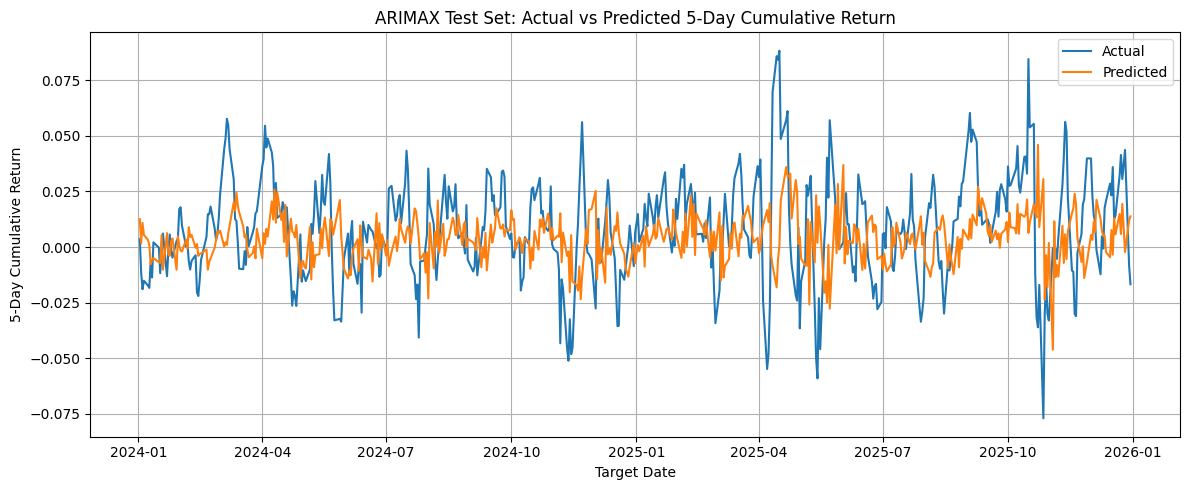

In [26]:
plot_df = final_test_pred_df.copy()
plot_df = plot_df.sort_values(TARGET_DATE_COL).reset_index(drop=True)

plt.figure(figsize=(12, 5))
plt.plot(plot_df[TARGET_DATE_COL], plot_df[TARGET_COL], label="Actual")
plt.plot(plot_df[TARGET_DATE_COL], plot_df["PRED"], label="Predicted")
plt.title("ARIMAX Test Set: Actual vs Predicted 5-Day Cumulative Return")
plt.xlabel("Target Date")
plt.ylabel("5-Day Cumulative Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## **Final Summary**

In [27]:
summary = {
    "model": "ARIMAX",
    "target": TARGET_COL,
    "selection_rule": "best order selected by validation MAE; RMSE and DA used as secondary checks",
    "best_order": BEST_ORDER,
    "best_trend": BEST_TREND,
    "best_package": BEST_PACKAGE,
    "best_exog_cols": BEST_EXOG_COLS,
    "validation_metrics_best_package": {
        "MAE": float(BEST_STAGE_B["MAE"]),
        "RMSE": float(BEST_STAGE_B["RMSE"]),
        "DA": float(BEST_STAGE_B["DA"]),
    },
    "test_metrics": {
        "MAE": float(final_test_metrics["MAE"]),
        "RMSE": float(final_test_metrics["RMSE"]),
        "DA": float(final_test_metrics["DA"]),
    },
    "benchmark_metrics": {
        "ZERO": zero_metrics,
        "PERSISTENCE": persist_metrics,
    },
    "row_counts": {
        "train": int(len(train_df)),
        "validation": int(len(val_df)),
        "test": int(len(test_df)),
        "train_plus_validation": int(len(train_val_df)),
    },
    "files": {
        "stage_a_results": str(stage_a_path),
        "stage_b_results": str(stage_b_path),
        "validation_predictions": str(val_pred_path),
        "test_predictions": str(test_pred_path),
        "benchmarks": str(benchmark_path),
    },
}

summary_path = RESULTS_DIR / "arimax_summary_5d.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("Saved:", summary_path)

Saved: C:\Users\Afzi\Documents\BINUS\0. SKRIPSI\gold_forecasting_skripsi\results\arimax_5d\arimax_summary_5d.json


In [28]:
print("\n===== ARIMAX SUMMARY =====")
print("Train rows        :", len(train_df))
print("Validation rows   :", len(val_df))
print("Test rows         :", len(test_df))
print("Best order        :", BEST_ORDER)
print("Best trend        :", BEST_TREND)
print("Best package      :", BEST_PACKAGE)
print("Best exog cols    :", BEST_EXOG_COLS)
print(f"Validation MAE    : {BEST_STAGE_B['MAE']:.6f}")
print(f"Validation RMSE   : {BEST_STAGE_B['RMSE']:.6f}")
print(f"Validation DA     : {BEST_STAGE_B['DA']:.4f}")
print(f"Test MAE          : {final_test_metrics['MAE']:.6f}")
print(f"Test RMSE         : {final_test_metrics['RMSE']:.6f}")
print(f"Test DA           : {final_test_metrics['DA']:.4f}")
print("\nBenchmarks")
print(f"Zero MAE          : {zero_metrics['MAE']:.6f}")
print(f"Zero RMSE         : {zero_metrics['RMSE']:.6f}")
print(f"Zero DA           : {zero_metrics['DA']:.4f}")
print(f"Persistence MAE   : {persist_metrics['MAE']:.6f}")
print(f"Persistence RMSE  : {persist_metrics['RMSE']:.6f}")
print(f"Persistence DA    : {persist_metrics['DA']:.4f}")


===== ARIMAX SUMMARY =====
Train rows        : 3263
Validation rows   : 250
Test rows         : 503
Best order        : (0, 0, 1)
Best trend        : c
Best package      : FULL
Best exog cols    : ['DXY_RET', 'SP500_RET', 'OIL_RET', 'US10Y_CHANGE', 'VIX_LEVEL']
Validation MAE    : 0.014190
Validation RMSE   : 0.018560
Validation DA     : 0.5920
Test MAE          : 0.020588
Test RMSE         : 0.026676
Test DA           : 0.5109

Benchmarks
Zero MAE          : 0.019073
Zero RMSE         : 0.024538
Zero DA           : 0.3459
Persistence MAE   : 0.026170
Persistence RMSE  : 0.034550
Persistence DA    : 0.5308
